<a href="https://colab.research.google.com/github/kuruvajayanth12/Neural-Networks-and-Deep-Learning/blob/main/NNDL_EXP8_LSTM_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - loss: 0.2016 - val_loss: 0.1167
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0931 - val_loss: 0.0908
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0827 - val_loss: 0.0852
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0789 - val_loss: 0.0745
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.1044 - val_loss: 0.1101
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0856 - val_loss: 0.0749
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0761 - val_loss: 0.0749
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0676 - val_loss: 0.0617
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0612 - val_loss: 0.0506
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0492 - val_loss: 0.0383
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0324 - val_loss: 0.0232
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.

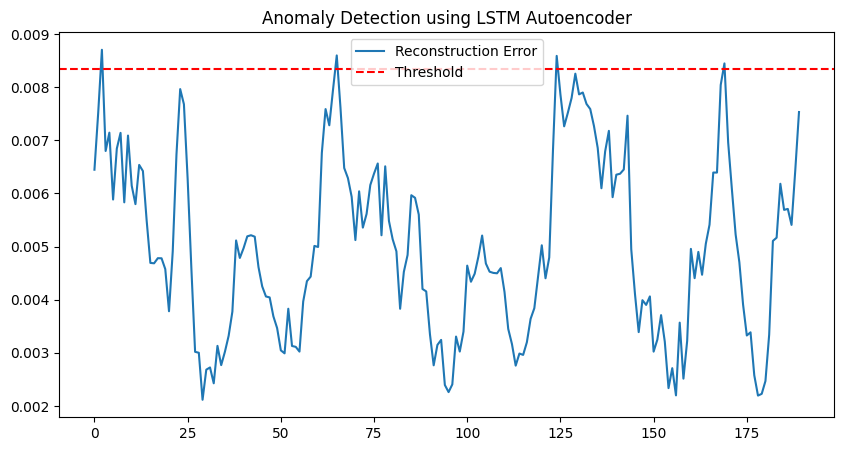

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# -----------------------------
# 1. Create / Load Dataset
# -----------------------------
# Example: synthetic "normal system activity"
np.random.seed(42)
time_steps = 50

data = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)
data = data.reshape(-1, 1)

# -----------------------------
# 2. Normalize
# -----------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -----------------------------
# 3. Create sequences
# -----------------------------
def create_sequences(data, time_steps):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
    return np.array(X)

X = create_sequences(data_scaled, time_steps)

# -----------------------------
# 4. Split (train only on NORMAL data)
# -----------------------------
train_size = int(0.8 * len(X))
X_train = X[:train_size]
X_test = X[train_size:]

# -----------------------------
# 5. Build LSTM Autoencoder
# -----------------------------
inputs = Input(shape=(time_steps, 1))

# Encoder
encoded = LSTM(64, activation='relu')(inputs)

# Repeat vector
decoded = RepeatVector(time_steps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

# Model
autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# -----------------------------
# 6. Train (only normal patterns)
# -----------------------------
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# -----------------------------
# 7. Reconstruction
# -----------------------------
X_pred = autoencoder.predict(X_test)

# -----------------------------
# 8. Reconstruction Error
# -----------------------------
mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

# Threshold (simple method)
threshold = np.mean(mse) + 2*np.std(mse)

# Detect anomalies
anomalies = mse > threshold

print("Threshold:", threshold)
print("Anomalies detected:", np.sum(anomalies))

# -----------------------------
# 9. Plot errors
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.title("Anomaly Detection using LSTM Autoencoder")
plt.show()